# 1. Khai báo thư viện và cấu hình ban đầu


In [1]:
!pip install -q kagglehub seaborn

import os
# Đảm bảo mọi thứ (kể cả dataset) lưu ở thư mục hiện tại
PROJECT_DIR = os.path.abspath(os.getcwd())
os.environ['KAGGLEHUB_CACHE'] = os.path.join(PROJECT_DIR, 'dataset_cache')
import copy
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.models as tv_models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import kagglehub

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Đang sử dụng thiết bị: {device}')


Đang sử dụng thiết bị: cuda


# 2. Tải và xử lý dữ liệu


In [2]:
path = kagglehub.dataset_download('nqa112/vietnamese-bike-and-motorbike')
print('Đường dẫn tải dataset:', path)

all_image_paths = []
labels = []
motor_aliases = ['motorbike', 'motor', 'xe may', 'xe_may']
bike_aliases = ['bike', 'xe dap', 'xe_dap', 'bicycle']

for root, _, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')):
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, path).lower()
            is_motor = any(alias in rel_path for alias in motor_aliases)
            is_bike = any(alias in rel_path for alias in bike_aliases)
            if is_motor:
                all_image_paths.append(full_path)
                labels.append(1)
            elif is_bike:
                all_image_paths.append(full_path)
                labels.append(0)

class_names = ['Bike', 'Motorbike']
print(f'Tổng số ảnh thu thập được: {len(all_image_paths)}')

trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    all_image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels, test_size=0.2, stratify=trainval_labels, random_state=42
)

print(f'Tập Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}')


100%|██████████| 1.44G/1.44G [00:36<00:00, 42.6MB/s]

Extracting files...


Đường dẫn tải dataset: /content/dataset_cache/datasets/nqa112/vietnamese-bike-and-motorbike/versions/1
Tổng số ảnh thu thập được: 12118
Tập Train: 7755, Val: 1939, Test: 2424


# 3. DataLoaders


In [3]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

class BikeMotorbikeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        try:
            image = Image.open(path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0))
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label, path

train_dataset = BikeMotorbikeDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = BikeMotorbikeDataset(val_paths, val_labels, transform=val_test_transforms)
test_dataset = BikeMotorbikeDataset(test_paths, test_labels, transform=val_test_transforms)

batch_size = 32
num_workers = 2 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)


# 4. Hàm Huấn luyện và Cấu trúc Mô hình


In [4]:
def train_model(model, criterion, optimizer, num_epochs=10, history=None):
    if history is None:
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
                dataset_size = len(train_dataset)
            else:
                model.eval()
                dataloader = val_loader
                dataset_size = len(val_dataset)

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels, _ in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects.double() / dataset_size
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(float(epoch_loss))
                history['train_acc'].append(float(epoch_acc))
            else:
                history['val_loss'].append(float(epoch_loss))
                history['val_acc'].append(float(epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                
    model.load_state_dict(best_model_wts)
    return model, history

weights = tv_models.ResNet50_Weights.IMAGENET1K_V1
model = tv_models.resnet50(weights=weights)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)
criterion = nn.CrossEntropyLoss()


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 121MB/s]


# 5. Thực thi Huấn luyện
*(Lưu ý: Nếu bạn đã có est_model.pth thì có thể KHÔNG CẦN CHẠY cell này để tiết kiệm thời gian, hãy sang thẳng cell dưới để load model)*


In [5]:
# Chỉ chạy huấn luyện nếu chưa có best_model.pth (Hoặc bạn có thể xóa file để train lại)
if not os.path.exists(os.path.join(PROJECT_DIR, 'best_model.pth')):
    print('=== BẮT ĐẦU GIAI ĐOẠN 1 (Train layer cuối) ===')
    for param in model.parameters(): param.requires_grad = False
    for param in model.fc.parameters(): param.requires_grad = True
    optimizer_ft_1 = optim.Adam(model.fc.parameters(), lr=1e-3)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    model, history = train_model(model, criterion, optimizer_ft_1, num_epochs=5, history=history)

    print('\n=== BẮT ĐẦU GIAI ĐOẠN 2 (Fine-tuning toàn bộ) ===')
    for param in model.parameters(): param.requires_grad = True
    optimizer_ft_2 = optim.Adam(model.parameters(), lr=1e-4)
    model, history = train_model(model, criterion, optimizer_ft_2, num_epochs=15, history=history)

    # Lưu trọng số mô hình
    torch.save(model.state_dict(), os.path.join(PROJECT_DIR, 'best_model.pth'))
    print('Đã lưu trọng số mô hình tại best_model.pth')
    
    # Lưu lịch sử huấn luyện để sau này vẽ lại biểu đồ mà không cần train
    with open(os.path.join(PROJECT_DIR, 'training_history.json'), 'w') as f:
        json.dump(history, f)
    print('Đã lưu lịch sử huấn luyện tại training_history.json')
else:
    print('Đã tìm thấy best_model.pth, bỏ qua quá trình huấn luyện! Hãy chạy cell tiếp theo.')


=== BẮT ĐẦU GIAI ĐOẠN 1 (Train layer cuối) ===
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.1449 Acc: 0.9509


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Val Loss: 0.0463 Acc: 0.9850
Epoch 2/5


...

Val Loss: 0.0148 Acc: 0.9933
Epoch 15/15


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.0023 Acc: 0.9991


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Val Loss: 0.0145 Acc: 0.9969
Đã lưu trọng số mô hình tại best_model.pth
Đã lưu lịch sử huấn luyện tại training_history.json


# 6. Vẽ biểu đồ Train/Val Loss và Accuracy


Đã lưu biểu đồ vào file loss_accuracy_plot.png


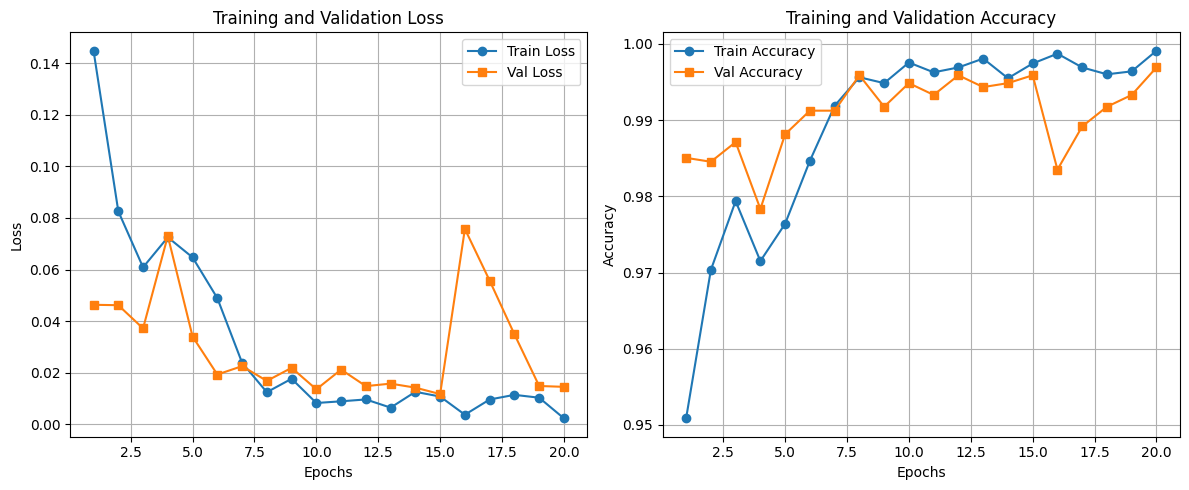

In [6]:
# Vẽ biểu đồ dựa trên lịch sử đã lưu
if os.path.exists(os.path.join(PROJECT_DIR, 'training_history.json')):
    with open(os.path.join(PROJECT_DIR, 'training_history.json'), 'r') as f:
        history = json.load(f)
        
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Biểu đồ Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    # Bỏ qua dòng này nếu mảng bị lệch do lỗi json cũ, dùng length tương đối
    val_epochs = np.linspace(1, len(history['train_loss']), len(history['val_loss']))
    plt.plot(val_epochs, history['val_loss'], label='Val Loss', marker='s')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Biểu đồ Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(val_epochs, history['val_acc'], label='Val Accuracy', marker='s')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    # Lưu trực tiếp vào máy tính
    plt.savefig(os.path.join(PROJECT_DIR, 'loss_accuracy_plot.png'), dpi=300)
    print('Đã lưu biểu đồ vào file loss_accuracy_plot.png')
    plt.show()
else:
    print('Chưa có lịch sử huấn luyện. Hãy chạy cell huấn luyện trước.')


# 7. Đánh giá mô hình trên tập Test


Đã tải thành công trọng số từ best_model.pth

Đang chạy dự đoán trên tập Test...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        Bike     0.9992    0.9950    0.9971      1209
   Motorbike     0.9951    0.9992    0.9971      1215

    accuracy                         0.9971      2424
   macro avg     0.9971    0.9971    0.9971      2424
weighted avg     0.9971    0.9971    0.9971      2424

Tổng Test Accuracy: 99.71%
Đã lưu kết quả đánh giá tại training_results.txt trên máy.
Đã lưu biểu đồ ma trận nhầm lẫn tại confusion_matrix.png


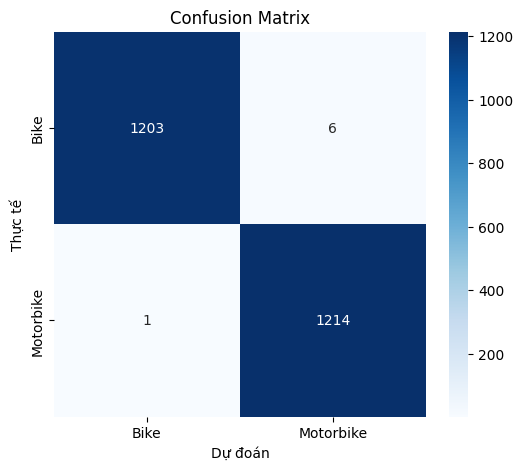

In [7]:
# Tải lại trọng số tốt nhất trước khi test
if os.path.exists(os.path.join(PROJECT_DIR, 'best_model.pth')):
    model.load_state_dict(torch.load(os.path.join(PROJECT_DIR, 'best_model.pth'), map_location=device, weights_only=True))
    print('Đã tải thành công trọng số từ best_model.pth')
else:
    print('CẢNH BÁO: Không tìm thấy best_model.pth, đang dùng model hiện tại (có thể chưa train).')

print('\nĐang chạy dự đoán trên tập Test...')
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels, paths in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print('\n=== CLASSIFICATION REPORT ===')
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
acc_text = f'Tổng Test Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%'
print(report)
print(acc_text)

# Lưu lại log kết quả huấn luyện VÀO MÁY TÍNH
with open(os.path.join(PROJECT_DIR, 'training_results.txt'), 'w', encoding='utf-8') as f:
    f.write('=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===\n')
    f.write(report + '\n')
    f.write(acc_text + '\n')
print('Đã lưu kết quả đánh giá tại training_results.txt trên máy.')

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
# Lưu biểu đồ matrix VÀO MÁY TÍNH
plt.savefig(os.path.join(PROJECT_DIR, 'confusion_matrix.png'), dpi=300)
print('Đã lưu biểu đồ ma trận nhầm lẫn tại confusion_matrix.png')
plt.show()
